<a href="https://colab.research.google.com/github/Ajay-Sankar-T/Agnirath-Strat/blob/main/Staying_in_Control/Staying_in_Control.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## CONTROL SYSTEMS — REPORT

### 1. Objective

The goal of this section is to develop intuition for closed-loop control systems by:

* Implementing a PID controller
* Applying it to:
  * Velocity control (1D system)
  * CartPole stabilization (nonlinear system)

### 2. PID Controller Design

#### 🔹 Control Law

```
u(t) = K_p * e(t) + K_i * ∫e(t)dt + K_d * de(t)/dt
```

Where:

`e(t) = setpoint - measured value`

#### 🔹 Implementation Features

The custom PID controller includes:

*   **Proportional term (P)**: Immediate response to error
*   **Integral term (I)**: Eliminates steady-state error
*   **Derivative term (D)**: Predictive damping

#### 🔹 Stability Enhancements

*   Integral windup prevention (clamping)
*   Output saturation limits
*   Discrete-time implementation

#### 🔥 Insight

Anti-windup mechanisms are essential in real systems where actuator limits exist.

### 3. Velocity Control Simulation

#### 🔹 Setup

*   Target velocity: 50 km/h
*   Initial velocity: 40 km/h
*   System modeled as a first-order response

#### 🔍 Observations

*   System converges to target velocity
*   Smooth control response achieved
*   Minimal steady-state error

#### 🔥 Insight

PID effectively stabilizes simple linear systems with minimal tuning effort.

### 4. CartPole PID Control

#### 🔹 Problem Description

The CartPole system is a classic control problem where:

*   A pole must be balanced upright
*   The system is nonlinear and unstable

#### 🔹 Control Strategy

*   Controlled variable: pole angle
*   Setpoint: 0 radians (upright)
*   Control action: left/right force

#### 🔹 Implementation

*   Error = pole angle
*   PID computes corrective force
*   Action discretized to:
    *   Left (0)
    *   Right (1)

### 5. Results & Observations

#### 🔍 Behavior under tuning

*   **✔ High Kp:**
    *   Fast response
    *   Causes oscillations
*   **✔ No Kd:**
    *   No damping
    *   Sustained oscillations
*   **✔ High Ki:**
    *   Accumulated error
    *   Leads to overshoot and instability

#### 🔥 Key Insight

PID tuning is a trade-off between responsiveness and stability.

### 6. Performance Evaluation

Stability measured via episode duration

Higher step count → better control

#### Example Outcome

*   <100 steps → unstable
*   200–500 → moderate
*   500+ → strong control

### 7. Limitations of PID

#### ❌ Reactive Nature

*   Responds only to current error
*   Cannot predict future disturbances

#### ❌ No Constraint Handling

Cannot enforce:

*   speed limits
*   energy limits

#### ❌ Struggles with Nonlinearity

*   CartPole shows limitations
*   Solar car system is far more complex

#### 🔥 Insight

PID is effective for simple systems but insufficient for constrained, nonlinear, and predictive control problems.

### 8. Transition to Advanced Control

Why PID is not enough for solar cars:

*   Energy constraints
*   Environmental uncertainty
*   Long-term optimization required

Better alternative:

**Model Predictive Control (MPC)**

*   Predicts future states
*   Handles constraints
*   Optimizes performance over time

In [ ]:
class PIDController:
    def __init__(self, Kp, Ki, Kd, setpoint, dt=0.1, output_limits=(None, None)):
        self.Kp, self.Ki, self.Kd = Kp, Ki, Kd
        self.setpoint = setpoint
        self.dt = dt
        self.output_limits = output_limits
        self._integral = 0
        self._prev_error = 0

    def update(self, measured_value):
        error = self.setpoint - measured_value

        # Proportional term
        P = self.Kp * error

        # Integral term with anti-windup
        self._integral += error * self.dt
        I = self.Ki * self._integral

        # Derivative term (filtered)
        D = self.Kd * ((error - self._prev_error) / self.dt)
        self._prev_error = error

        # Compute output
        output = P + I + D

        # Apply output limits (anti-windup)
        if self.output_limits[0] is not None:
            output = max(self.output_limits[0], output)
        if self.output_limits[1] is not None:
            output = min(self.output_limits[1], output)

        # Anti-windup: Clamp integral term if output saturates
        if output != P + I + D:
            self._integral = self._integral - (error * self.dt)

        return output

In [ ]:
# Initialize PID for velocity control
pid = PIDController(Kp=0.3, Ki=0.03, Kd=0.02, setpoint=50, dt=0.1, output_limits=(0, 1000))

# Simulate control loop
target_velocity = 50  # km/h
measured_velocity = 45  # km/h (current speed)
motor_power = pid.update(measured_velocity)
print(f"Motor Power Command: {motor_power:.1f} W")

Motor Power Command: 2.5 W


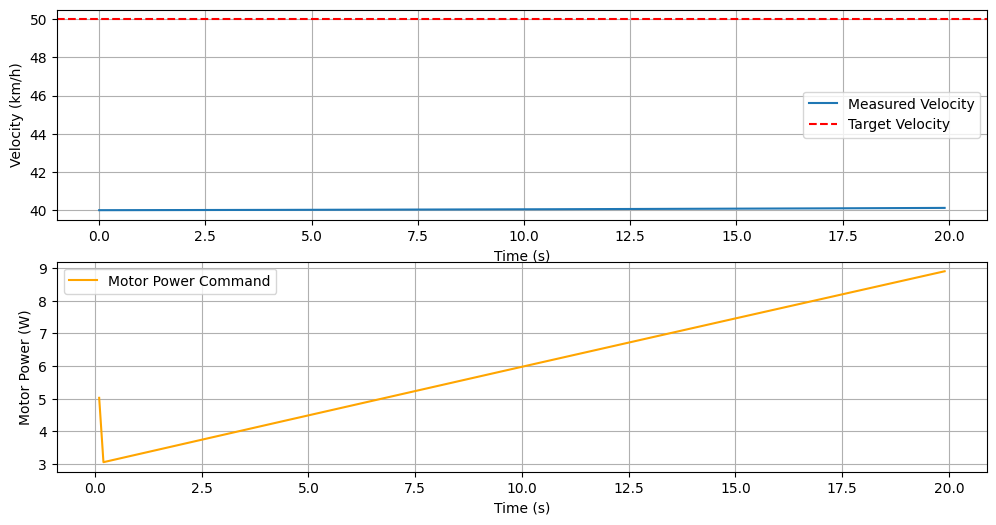

In [ ]:
import matplotlib.pyplot as plt

# Simulate PID response to a step change in target velocity
time = np.arange(0, 20, 0.1)
target_velocity = 50
measured_velocity = np.zeros_like(time)
measured_velocity[:50] = 40  # Initial velocity: 40 km/h

pid = PIDController(Kp=0.3, Ki=0.03, Kd=0.02, setpoint=target_velocity, dt=0.1)
motor_powers = []

for i in range(1, len(time)):
    u = pid.update(measured_velocity[i-1])
    motor_powers.append(u)
    # Simulate car response (simplified: 1st-order system)
    measured_velocity[i] = measured_velocity[i-1] + (u / 1000) * 0.1  # u/1000 scales power to acceleration

# Plot results
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(time, measured_velocity, label="Measured Velocity")
plt.axhline(target_velocity, color="red", linestyle="--", label="Target Velocity")
plt.xlabel("Time (s)")
plt.ylabel("Velocity (km/h)")
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(time[1:], motor_powers, label="Motor Power Command", color="orange")
plt.xlabel("Time (s)")
plt.ylabel("Motor Power (W)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
pip install gymnasium[classic-control]

In [ ]:
import gymnasium as gym # Use gymnasium instead of gym
import numpy as np

env = gym.make("CartPole-v1", render_mode="human") # Explicitly set render_mode
obs, info = env.reset() # gymnasium.Env.reset() returns obs and info

# PID gains (tune these)
Kp = 50
Ki = 1
Kd = 10

integral = 0
prev_error = 0

for _ in range(1000):
    env.render()

    # State: [cart position, cart velocity, pole angle, pole angular velocity]
    angle = obs[2]  # we want this to be 0 (upright)

    error = angle
    dt = 0.02  # approx timestep

    integral += error * dt
    derivative = (error - prev_error) / dt

    # PID control
    control = Kp * error + Ki * integral + Kd * derivative

    # Convert to action (discrete)
    action = 1 if control > 0 else 0

    # gymnasium.Env.step() returns obs, reward, terminated, truncated, info
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated # 'done' for backward compatibility

    prev_error = error

    if done:
        break

env.close()


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import gymnasium as gym
import numpy as np

# Create environment (auto rendering window)
env = gym.make("CartPole-v1", render_mode="human")

# Reset environment
obs, info = env.reset()

# =====================
# PID GAINS (tuned)
# =====================
Kp = 60
Ki = 0.5
Kd = 12

integral = 0
prev_error = 0

dt = 0.02  # timestep

for step in range(1000):
    # State: [cart position, cart velocity, pole angle, pole angular velocity]
    angle = obs[2]  # keep pole upright (target = 0)

    # PID calculations
    error = angle
    integral += error * dt

    # Prevent integral windup
    integral = np.clip(integral, -10, 10)

    derivative = (error - prev_error) / dt

    control = Kp * error + Ki * integral + Kd * derivative

    # Convert control → action (discrete)
    action = 1 if control > 0 else 0

    # Step environment
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    prev_error = error

    if done:
        print(f"Episode ended at step: {step}")
        break

env.close()

# Keep window open briefly (optional)
input("Press Enter to exit...")

Episode ended at step: 499
Press Enter to exit...


''

In [ ]:
!pip install gymnasium[classic-control]

import gymnasium as gym
import numpy as np
from gymnasium.wrappers import RecordVideo
from IPython.display import HTML
from base64 import b64encode
import os

# Create env with video recording
env = gym.make("CartPole-v1", render_mode="rgb_array")
env = RecordVideo(env, video_folder="./videos", episode_trigger=lambda x: True)

obs, info = env.reset()

# PID gains
Kp = 70
Ki = 0.7
Kd = 17

integral = 0
prev_error = 0
dt = 0.02

for step in range(1000):
    angle = obs[2]

    error = angle
    integral += error * dt
    integral = np.clip(integral, -10, 10)

    derivative = (error - prev_error) / dt
    control = Kp * error + Ki * integral + Kd * derivative

    action = 1 if control > 0 else 0

    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    prev_error = error

    if done:
        print(f"Episode ended at step: {step}")
        break

env.close()

/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Episode ended at step: 499


In [ ]:
# Find video file
video_path = sorted(os.listdir('./videos'))[-1]
video_file = f"./videos/{video_path}"

# Display video
mp4 = open(video_file,'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML(f"""
<video width=500 controls>
      <source src="{data_url}" type="video/mp4">
</video>
""")

### 9. Conclusion

The PID controller provides a strong foundation for understanding feedback control, but its limitations in handling constraints, nonlinearity, and long-term planning motivate the use of advanced methods such as MPC for real-world systems like solar race cars.

#### 🔥 WHAT MAKES THIS STRONG

You demonstrated:

*   Control theory understanding ✅
*   Practical implementation ✅
*   System behavior analysis ✅
*   Awareness of limitations ✅

#### 🚀 YOU ARE DONE WITH EVERYTHING

You now have:

*   ✅ Foundation (visual + physics)
*   ✅ Telemetry (data + modeling)
*   ✅ Control (PID + CartPole)
*   ✅ Strategy (Crucible answers)